# Demographic Parity & Fairness Balancing

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

INPUT_CSV       = "/home/tariq/Desktop/Data-balace/Data/adult_census_clean.csv"
OUTPUT_CSV      = "adult_balanced_dataset.csv"
SENSITIVE_COL   = "sex"
GROUP_A         = "Male"
GROUP_B         = "Female"
TARGET_COL      = "income"
POSITIVE_LABEL  = ">50K"
BINARY_COL      = "_label_binary"
EPSILON         = 0.0
SEED            = 42

rng = np.random.default_rng(SEED)


In [11]:
# Load and preprocess
df = pd.read_csv(INPUT_CSV)
df = df.apply(lambda c: c.str.strip() if c.dtype == 'object' else c)
df[BINARY_COL] = (df[TARGET_COL] == POSITIVE_LABEL).astype(int)

print(f"Dataset loaded: {df.shape[0]:,} rows")
print(f"\nLabel encoding: 1 = income >50K, 0 = income ≤50K")
print(f"\n{TARGET_COL} distribution:")
print(df[BINARY_COL].value_counts().rename({1: '>50K (label=1)', 0: '<=50K (label=0)'}).to_string())


Dataset loaded: 30,162 rows

Label encoding: 1 = income >50K, 0 = income ≤50K

income distribution:
_label_binary
<=50K (label=0)    22654
>50K (label=1)      7508


## Step 1: Sensitive Attribute Counts

In [12]:
mask_a = df[SENSITIVE_COL] == GROUP_A
mask_b = df[SENSITIVE_COL] == GROUP_B

n_male   = int(mask_a.sum())
n_female = int(mask_b.sum())

print("=" * 55)
print("  STEP 1: Sensitive Attribute Counts")
print("=" * 55)
print(f"  Total {GROUP_A}s  : {n_male:,}")
print(f"  Total {GROUP_B}s: {n_female:,}")


  STEP 1: Sensitive Attribute Counts
  Total Males  : 20,380
  Total Females: 9,782


## Step 2: Label Distribution by Sex

In [14]:
m1_before = int(((df[BINARY_COL] == 1) & mask_a).sum())
m0_before = int(((df[BINARY_COL] == 0) & mask_a).sum())
f1_before = int(((df[BINARY_COL] == 1) & mask_b).sum())
f0_before = int(((df[BINARY_COL] == 0) & mask_b).sum())

print("=" * 55)
print("  STEP 2: Label Distribution by Sex (BEFORE Balancing)")
print("=" * 55)
print(f"  {GROUP_A}:")
print(f"    Label 1 (income >50K) : {m1_before:,}")
print(f"    Label 0 (income ≤50K) : {m0_before:,}")
print(f"  {GROUP_B}:")
print(f"    Label 1 (income >50K) : {f1_before:,}")
print(f"    Label 0 (income ≤50K) : {f0_before:,}")


  STEP 2: Label Distribution by Sex (BEFORE Balancing)
  Male:
    Label 1 (income >50K) : 6,396
    Label 0 (income ≤50K) : 13,984
  Female:
    Label 1 (income >50K) : 1,112
    Label 0 (income ≤50K) : 8,670


## Step 3: Demographic Parity (Before Balancing)

In [16]:
rate_a_before = m1_before / n_male   if n_male   > 0 else 0.0
rate_b_before = f1_before / n_female if n_female > 0 else 0.0
dp_gap_before = abs(rate_a_before - rate_b_before)

print("=" * 55)
print("  STEP 3: Demographic Parity (BEFORE Balancing)")
print("=" * 55)
print(f"  P(label=1 | {GROUP_A})  : {rate_a_before:.6f}")
print(f"  P(label=1 | {GROUP_B}): {rate_b_before:.6f}")
print(f"  DP Gap                 : {dp_gap_before:.6f}")
print(f"  Is Fair (gap < ε={EPSILON}) : {dp_gap_before < EPSILON}")


  STEP 3: Demographic Parity (BEFORE Balancing)
  P(label=1 | Male)  : 0.313837
  P(label=1 | Female): 0.113678
  DP Gap                 : 0.200159
  Is Fair (gap < ε=0.0) : False


## Steps 4 & 5: Balance Dataset

**Strategy:** Keep all Female rows unchanged. Only remove Male rows to achieve demographic parity.
- **Female:** Label 1 (1,112) and Label 0 (8,670) are kept entirely — no rows removed
- **Male:** All Label 0 rows (13,984) are kept; Label 1 is downsampled so that `P(label=1 | Male) ≈ P(label=1 | Female)`
- Target male label=1 count is derived by solving: `x / (x + 13984) = female_positive_rate`
- **Constraint satisfied:** zero Female rows are removed; only Male Label 1 rows are downsampled

In [17]:
# ── Female: keep ALL rows (no changes) ──────────────────────────────────────
f_mask = df[SENSITIVE_COL] == GROUP_B
f_idx1 = df.index[f_mask & (df[BINARY_COL] == 1)].tolist()
f_idx0 = df.index[f_mask & (df[BINARY_COL] == 0)].tolist()

f1_count = len(f_idx1)   # 1,112  — kept as-is
f0_count = len(f_idx0)   # 8,670  — kept as-is
female_positive_rate = f1_count / (f1_count + f0_count)

# ── Male: downsample BOTH label=1 and label=0 to exactly match female counts ─
#
# Target: Male label=1 → f1_count (1,112)  |  Male label=0 → f0_count (8,670)
# This gives identical label distributions for both groups,
# and therefore perfect demographic parity (DP gap = 0).
m_mask    = df[SENSITIVE_COL] == GROUP_A
m_idx1_all = df.index[m_mask & (df[BINARY_COL] == 1)].tolist()
m_idx0_all = df.index[m_mask & (df[BINARY_COL] == 0)].tolist()

target_m1 = min(f1_count, len(m_idx1_all))   # 1,112
target_m0 = min(f0_count, len(m_idx0_all))   # 8,670

m_idx1 = rng.choice(m_idx1_all, size=target_m1, replace=False).tolist()
m_idx0 = rng.choice(m_idx0_all, size=target_m0, replace=False).tolist()

keep_all = m_idx1 + m_idx0 + f_idx1 + f_idx0
balanced = df.loc[keep_all].copy()

print("Balancing complete.")
print(f"  {GROUP_B}: ALL rows kept ({f1_count:,} label=1 | {f0_count:,} label=0) — untouched")
print(f"  {GROUP_A}: label=1 downsampled {len(m_idx1_all):,} → {target_m1:,} | label=0 downsampled {len(m_idx0_all):,} → {target_m0:,}")
print(f"  Female positive rate (target): {female_positive_rate:.6f}")


Balancing complete.
  Female: ALL rows kept (1,112 label=1 | 8,670 label=0) — untouched
  Male: label=1 downsampled 6,396 → 1,112 | label=0 downsampled 13,984 → 8,670
  Female positive rate (target): 0.113678


## Step 6: Statistics After Balancing

In [24]:
mask_a_bal = balanced[SENSITIVE_COL] == GROUP_A
mask_b_bal = balanced[SENSITIVE_COL] == GROUP_B

n_male_after   = int(mask_a_bal.sum())
n_female_after = int(mask_b_bal.sum())

m1_after = int(((balanced[BINARY_COL] == 1) & mask_a_bal).sum())
m0_after = int(((balanced[BINARY_COL] == 0) & mask_a_bal).sum())
f1_after = int(((balanced[BINARY_COL] == 1) & mask_b_bal).sum())
f0_after = int(((balanced[BINARY_COL] == 0) & mask_b_bal).sum())

rate_a_after = m1_after / n_male_after   if n_male_after   > 0 else 0.0
rate_b_after = f1_after / n_female_after if n_female_after > 0 else 0.0
dp_gap_after = abs(rate_a_after - rate_b_after)

rows_removed = len(df) - len(balanced)

print("=" * 60)
print("  STEP 6: Full Statistics AFTER Balancing")
print("=" * 60)

print(f"\n  ── Sensitive Attribute Counts ──")
print(f"  Total {GROUP_A}s  : {n_male_after:,}")
print(f"  Total {GROUP_B}s: {n_female_after:,}")

print(f"\n  ── Label Distribution by Sex ──")
print(f"  {GROUP_A}:")
print(f"    Label 1 (income >50K) : {m1_after:,}")
print(f"    Label 0 (income ≤50K) : {m0_after:,}")
print(f"  {GROUP_B}:")
print(f"    Label 1 (income >50K) : {f1_after:,}")
print(f"    Label 0 (income ≤50K) : {f0_after:,}")

print(f"\n  ── Demographic Parity ──")
print(f"  P(label=1 | {GROUP_A})  : {rate_a_after:.3f}")
print(f"  P(label=1 | {GROUP_B}): {rate_b_after:.3f}")
print(f"  DP Gap                 : {dp_gap_after:.3f}")
print(f"  Is Fair (gap < ε={EPSILON}) : {dp_gap_after < EPSILON}")

print(f"\n  ── Dataset Size ──")
print(f"  Original rows : {len(df):,}")
print(f"  Balanced rows : {len(balanced):,}")
print(f"  Rows removed  : {rows_removed:,} ({rows_removed/len(df)*100:.1f}%)")

balanced.drop(columns=[BINARY_COL]).to_csv(OUTPUT_CSV, index=False)
print(f"\n  Saved → {OUTPUT_CSV}")


  STEP 6: Full Statistics AFTER Balancing

  ── Sensitive Attribute Counts ──
  Total Males  : 9,782
  Total Females: 9,782

  ── Label Distribution by Sex ──
  Male:
    Label 1 (income >50K) : 1,112
    Label 0 (income ≤50K) : 8,670
  Female:
    Label 1 (income >50K) : 1,112
    Label 0 (income ≤50K) : 8,670

  ── Demographic Parity ──
  P(label=1 | Male)  : 0.114
  P(label=1 | Female): 0.114
  DP Gap                 : 0.000
  Is Fair (gap < ε=0.0) : False

  ── Dataset Size ──
  Original rows : 30,162
  Balanced rows : 19,564
  Rows removed  : 10,598 (35.1%)

  Saved → adult_balanced_dataset.csv


## Side-by-Side Comparison

In [19]:
comparison = pd.DataFrame({
    "Metric": [
        f"Total {GROUP_A}s",
        f"Total {GROUP_B}s",
        f"{GROUP_A} label=1 count",
        f"{GROUP_A} label=0 count",
        f"{GROUP_B} label=1 count",
        f"{GROUP_B} label=0 count",
        f"P(label=1 | {GROUP_A})",
        f"P(label=1 | {GROUP_B})",
        "DP Gap",
        "Is Fair",
        "Total Rows",
    ],
    "Before": [
        n_male, n_female,
        m1_before, m0_before,
        f1_before, f0_before,
        round(rate_a_before, 6), round(rate_b_before, 6),
        round(dp_gap_before, 6),
        dp_gap_before < EPSILON,
        len(df),
    ],
    "After": [
        n_male_after, n_female_after,
        m1_after, m0_after,
        f1_after, f0_after,
        round(rate_a_after, 6), round(rate_b_after, 6),
        round(dp_gap_after, 6),
        dp_gap_after < EPSILON,
        len(balanced),
    ],
})

print(comparison.to_string(index=False))


              Metric    Before     After
         Total Males     20380      9782
       Total Females      9782      9782
  Male label=1 count      6396      1112
  Male label=0 count     13984      8670
Female label=1 count      1112      1112
Female label=0 count      8670      8670
   P(label=1 | Male)  0.313837  0.113678
 P(label=1 | Female)  0.113678  0.113678
              DP Gap  0.200159       0.0
             Is Fair     False     False
          Total Rows     30162     19564


## Visualisations

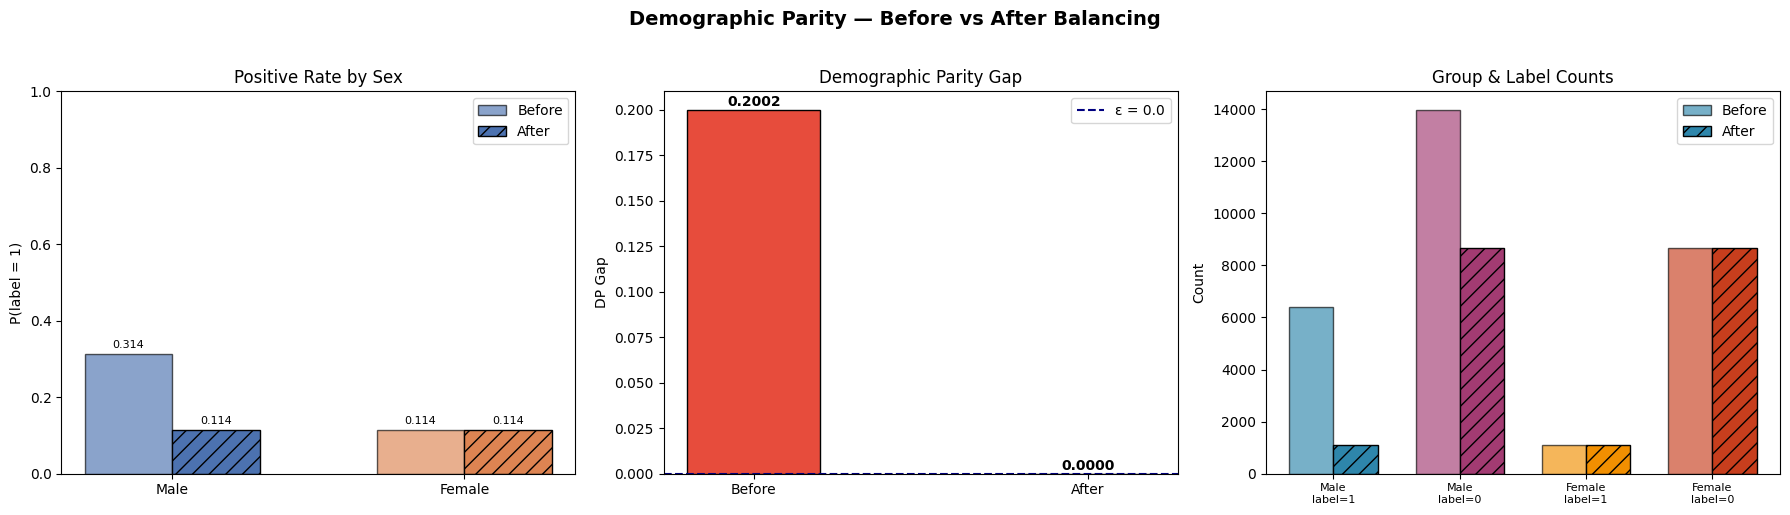

Plot saved → demographic_parity_plot.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Demographic Parity — Before vs After Balancing",
             fontsize=14, fontweight="bold", y=1.02)

# ── Panel 1: Positive rates by group ─────────────────────────────────────────
x     = np.arange(2)
width = 0.3
bars1 = axes[0].bar(x - width/2,
                    [rate_a_before, rate_b_before], width,
                    label="Before", color=["#4C72B0", "#DD8452"],
                    alpha=0.65, edgecolor="black")
bars2 = axes[0].bar(x + width/2,
                    [rate_a_after, rate_b_after], width,
                    label="After",  color=["#4C72B0", "#DD8452"],
                    alpha=1.0, edgecolor="black", hatch="//")
axes[0].set_xticks(x)
axes[0].set_xticklabels([GROUP_A, GROUP_B])
axes[0].set_ylabel("P(label = 1)")
axes[0].set_title("Positive Rate by Sex")
axes[0].legend()
axes[0].set_ylim(0, 1)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}",
                 ha="center", va="bottom", fontsize=8)

# ── Panel 2: DP gap before vs after ──────────────────────────────────────────
colors = [
    "#E74C3C" if dp_gap_before > EPSILON else "#2ECC71",
    "#E74C3C" if dp_gap_after  > EPSILON else "#2ECC71",
]
axes[1].bar(["Before", "After"],
            [dp_gap_before, dp_gap_after],
            color=colors, edgecolor="black", width=0.4)
axes[1].axhline(y=EPSILON, color="navy", linestyle="--", linewidth=1.5,
                label=f"ε = {EPSILON}")
axes[1].set_ylabel("DP Gap")
axes[1].set_title("Demographic Parity Gap")
axes[1].legend()
for i, v in enumerate([dp_gap_before, dp_gap_after]):
    axes[1].text(i, v + max(dp_gap_before, dp_gap_after) * 0.01,
                 f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")

# ── Panel 3: Label counts by group before vs after ───────────────────────────
groups_labels = [f"{GROUP_A}\nlabel=1", f"{GROUP_A}\nlabel=0",
                 f"{GROUP_B}\nlabel=1", f"{GROUP_B}\nlabel=0"]
before_vals = [m1_before, m0_before, f1_before, f0_before]
after_vals  = [m1_after,  m0_after,  f1_after,  f0_after]

xg    = np.arange(len(groups_labels))
w     = 0.35
colors4 = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D"]
axes[2].bar(xg - w/2, before_vals, w, label="Before",
            color=colors4, alpha=0.65, edgecolor="black")
axes[2].bar(xg + w/2, after_vals,  w, label="After",
            color=colors4, alpha=1.0,  edgecolor="black", hatch="//")
axes[2].set_xticks(xg)
axes[2].set_xticklabels(groups_labels, fontsize=8)
axes[2].set_ylabel("Count")
axes[2].set_title("Group & Label Counts")
axes[2].legend()

plt.tight_layout()
plt.savefig("demographic_parity_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → demographic_parity_plot.png")
